# ðŸš€ Notebook 07: Operationalization â€” Versioned Agents & Responses API

Moving from prototype to production. We'll use versioned agent definitions for safe iteration and the Responses API for conversations.

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath("../src"))
import nest_asyncio; nest_asyncio.apply()
from soc_workshop.settings import get_settings
from soc_workshop.clients import get_project_client, configure_tracing
from soc_workshop.incident_schema import Alert, InvestigationRecord
import pandas as pd
import matplotlib.pyplot as plt

settings = get_settings()
configure_tracing()
project_client = get_project_client(settings)

with open("../data/alerts.json", "r", encoding="utf-8") as f:
    alerts = json.load(f)

openai_client = project_client.get_openai_client()
alerts_df = pd.DataFrame(alerts)
alerts_df.head(3)

,alert_id,title,severity,description,timestamp,source,tactics,techniques,entities,raw_json
0,ALERT-2025-001,Suspicious PowerShell execution with encoded c...,High,PowerShell.exe was observed executing a Base64...,2025-03-07T14:32:11Z,Microsoft Defender for Endpoint,"[Execution, Command and Control]","[T1059.001, T1071.001]","[{'entity_type': 'host', 'value': 'WKS-FIN-PC0...",{'process_command_line': 'powershell.exe -nop ...
1,ALERT-2025-002,Anomalous sign-in from TOR exit node,High,User jdoe@contoso.com authenticated from IP 18...,2025-03-07T03:18:45Z,Microsoft Entra ID Protection,[Initial Access],[T1078],"[{'entity_type': 'user', 'value': 'jdoe@contos...","{'sign_in_id': 'si-2025-abc-002', 'location': ..."
2,ALERT-2025-003,Mass file encryption detected on network share,Critical,Host WKS-FIN-PC04 performed rapid file rename ...,2025-03-07T15:01:33Z,Microsoft Defender for Endpoint,[Impact],[T1486],"[{'entity_type': 'host', 'value': 'WKS-FIN-PC0...","{'files_affected': 1247, 'extension_new': '.lo..."


## Part 1: Agent Versioning â€” Safe Iteration

In [2]:
from azure.ai.projects.models import PromptAgentDefinition

agent_v1 = None
try:
    agent_v1 = project_client.agents.create_version(
        agent_name="soc-triage-agent",
        definition=PromptAgentDefinition(
            model=settings.model_deployment,
            instructions=(
                "You are a Tier-1 SOC Analyst. Perform initial triage on security alerts. "
                "Classify severity, summarize likely impact, map likely MITRE ATT&CK techniques, "
                "and recommend immediate containment actions. Keep output concise."
            ),
        ),
    )
    print(f"Created agent: {agent_v1.name}, version: {agent_v1.version}")
except AttributeError:
    print("Versioned agents require azure-ai-projects>=2.0.0b4")

Created agent: soc-triage-agent, version: 1


In [3]:
alert_001 = next((a for a in alerts if a.get("alert_id") == "ALERT-2025-001"), alerts[0])
alert_data = json.dumps(alert_001, indent=2)

v1_text = ""
if agent_v1 is not None:
    v1_prompt = f"Triage this alert:\n{alert_data}"
    v1_conversation = openai_client.conversations.create(
        items=[{"type": "message", "role": "user", "content": v1_prompt}]
    )
    response_v1 = openai_client.responses.create(
        conversation=v1_conversation.id,
        extra_body={
            "agent_reference": {
                "name": agent_v1.name,
                "version": agent_v1.version,
                "type": "agent_reference",
            }
        },
    )
    v1_text = response_v1.output_text
    print(v1_text)
    openai_client.conversations.delete(conversation_id=v1_conversation.id)
else:
    print("Skipping v1 test because versioned agent creation failed.")

**Initial Triage of ALERT-2025-001: Suspicious PowerShell execution with encoded command**

**Severity:**  
High

---

**Summary / Likely Impact:**  
A highly suspicious PowerShell was executed on host `WKS-FIN-PC04` (finance department), running a Base64-encoded payload that attempts to download a second-stage file from a known Cobalt Strike C2 IP (`198.51.100.23`). This activity is linked to the user `jdoe@contoso.com`. The file hash matches a known Cobalt Strike beacon. If successful, this likely enables remote attacker control, credential theft, lateral movement, and further payload deployment on a sensitive financial workstation.

---

**Mapped MITRE ATT&CK:**  
- **T1059.001**: PowerShell (Execution)
- **T1071.001**: Web Protocols (Command and Control)

---

**Immediate Containment Actions:**
1. **Isolate Host (`WKS-FIN-PC04`) from Network** immediately to prevent C2 communication and lateral movement.
2. **Invalidate User Credentials** for `jdoe@contoso.com` and force a password

In [4]:
agent_v2 = None
try:
    agent_v2 = project_client.agents.create_version(
        agent_name="soc-triage-agent",
        definition=PromptAgentDefinition(
            model=settings.model_deployment,
            instructions=(
                "You are a Senior Tier-1 SOC Analyst with enhanced capabilities. \
                Return a structured triage report with sections: Alert Summary, Severity Rationale, \
                MITRE ATT&CK Mapping (Tactic + Technique IDs where plausible), Evidence to Collect, \
                Immediate Containment, and Escalation Recommendation. \
                Prioritize accuracy, explicit uncertainty notes, and actionable steps."
            ),
        ),
    )
    print(f"Created agent: {agent_v2.name}, version: {agent_v2.version}")
except AttributeError:
    print("Versioned agents require azure-ai-projects>=2.0.0b4")

Created agent: soc-triage-agent, version: 2


In [5]:
v2_text = ""
if agent_v2 is not None:
    v2_prompt = f"Triage this alert:\n{alert_data}"
    v2_conversation = openai_client.conversations.create(
        items=[{"type": "message", "role": "user", "content": v2_prompt}]
    )
    response_v2 = openai_client.responses.create(
        conversation=v2_conversation.id,
        extra_body={
            "agent_reference": {
                "name": agent_v2.name,
                "version": agent_v2.version,
                "type": "agent_reference",
            }
        },
    )
    v2_text = response_v2.output_text
    print(v2_text)
    openai_client.conversations.delete(conversation_id=v2_conversation.id)
else:
    print("Skipping v2 test because versioned agent creation failed.")

**Triage Report**

---

### 1. Alert Summary

- **Alert ID:** ALERT-2025-001
- **Title:** Suspicious PowerShell execution with encoded command
- **Timestamp:** 2025-03-07T14:32:11Z
- **Source:** Microsoft Defender for Endpoint
- **Host:** WKS-FIN-PC04 (Finance Department)
- **User:** jdoe@contoso.com
- **Observed Activity:** PowerShell executed a Base64-encoded command, which downloads a second-stage payload from external IP (198.51.100.23). Behavior is consistent with Cobalt Strike stager activity.
- **Associated filehash:** a1b2c3d4e5f6a1b2c3d4e5f6a1b2c3d4e5f6a1b2c3d4e5f6a1b2c3d4e5f6a1b2 (Cobalt Strike beacon signature)

---

### 2. Severity Rationale

- **Severity:** High
- **Reasoning:**  
  - **Execution of encoded PowerShell:** This is a common attacker technique for obfuscating malicious activity.
  - **Attempts to download payload from known C2 IP:** 198.51.100.23 is tagged as Cobalt Strike. Second-stage download is indicative of an active attack.
  - **Risk scores:** Host (85)

In [6]:
comparison_df = pd.DataFrame([
    {
        "agent_version": getattr(agent_v1, "version", "n/a"),
        "label": "v1",
        "response_length": len(v1_text),
        "response_preview": v1_text[:500],
    },
    {
        "agent_version": getattr(agent_v2, "version", "n/a"),
        "label": "v2",
        "response_length": len(v2_text),
        "response_preview": v2_text[:500],
    },
])
comparison_df

,agent_version,label,response_length,response_preview
0,1,v1,1535,**Initial Triage of ALERT-2025-001: Suspicious...
1,2,v2,3679,**Triage Report**\n\n---\n\n### 1. Alert Summa...


## Part 2: Conversations with the Responses API

In [7]:
if agent_v2 is not None:
    part2_conversation = openai_client.conversations.create(
        items=[{"type": "message", "role": "user", "content": f"New alert received. Triage this:\n{alert_data}"}]
    )
    response1 = openai_client.responses.create(
        conversation=part2_conversation.id,
        extra_body={
            "agent_reference": {
                "name": "soc-07-triage-agent",
                "version": agent_v2.version,
                "type": "agent_reference",
            }
        },
    )

    response2 = openai_client.responses.create(
        conversation=part2_conversation.id,
        input="What MITRE techniques are involved? What's the recommended containment?",
        extra_body={
            "agent_reference": {
                "name": "soc-07-triage-agent",
                "version": agent_v2.version,
                "type": "agent_reference",
            }
        },
    )

    conversation_df = pd.DataFrame([
        {"turn": 1, "response_id": response1.id, "output_preview": response1.output_text[:400]},
        {"turn": 2, "response_id": response2.id, "output_preview": response2.output_text[:400]},
    ])
    conversation_df
    openai_client.conversations.delete(conversation_id=part2_conversation.id)
else:
    pd.DataFrame([{"status": "Skipping conversation: v2 not available"}])

## Part 3: Version Management â€” Listing, Comparing, Promoting

In [ ]:
version_rows = []
try:
    versions = project_client.agents.list_versions(agent_name="soc-07-triage-agent")
    for v in versions:
        definition = getattr(v, "definition", None)
        instructions = getattr(definition, "instructions", "") if definition is not None else getattr(v, "instructions", "")
        version_rows.append({
            "version": getattr(v, "version", "n/a"),
            "created_at": str(getattr(v, "created_at", "n/a")),
            "instructions_preview": (instructions or "")[:140],
        })
except AttributeError:
    print("Versioned agents require azure-ai-projects>=2.0.0b4")

versions_df = pd.DataFrame(version_rows)
versions_df

,version,created_at,instructions_preview
0,2,2026-03-09 12:37:32+00:00,You are a Senior Tier-1 SOC Analyst with enhan...
1,1,2026-03-09 12:37:19+00:00,You are a Tier-1 SOC Analyst. Perform initial ...


In [9]:
promoted_version = getattr(agent_v2, "version", None)
deployment_targets_df = pd.DataFrame([
    {"environment": "dev", "agent_name": "soc-triage-agent", "pinned_version": getattr(agent_v1, "version", "n/a")},
    {"environment": "prod", "agent_name": "soc-triage-agent", "pinned_version": promoted_version or "n/a"},
])
deployment_targets_df

,environment,agent_name,pinned_version
0,dev,soc-triage-agent,1
1,prod,soc-triage-agent,2


## Part 4: Dev vs Prod Agent Separation

In [ ]:
dev_agent = None
prod_agent = None

try:
    dev_agent = project_client.agents.create_version(
        agent_name="soc-07-triage-agent-dev",
        definition=PromptAgentDefinition(
            model=settings.model_deployment,
            instructions=(
                "[DEV] You are a SOC triage agent for experimentation. \
                Try richer hypotheses, call out uncertainty, and suggest additional telemetry to validate findings."
            ),
        ),
    )

    prod_agent = project_client.agents.create_version(
        agent_name="soc-07-triage-agent-prod",
        definition=PromptAgentDefinition(
            model=settings.model_deployment,
            instructions=(
                "[PROD] You are a stable SOC triage agent. \
                Provide deterministic, policy-aligned triage summaries with clear containment actions and escalation criteria."
            ),
        ),
    )
except AttributeError:
    print("Versioned agents require azure-ai-projects>=2.0.0b4")

pd.DataFrame([
    {"agent": "soc-triage-agent-dev", "version": getattr(dev_agent, "version", "n/a")},
    {"agent": "soc-triage-agent-prod", "version": getattr(prod_agent, "version", "n/a")},
])

,agent,version
0,soc-triage-agent-dev,1
1,soc-triage-agent-prod,1


## Part 5: Regression Testing Across Versions

In [11]:
test_alerts = [alerts[0], alerts[3] if len(alerts) > 3 else alerts[-1]]
results = {"v1": [], "v2": []}

if agent_v1 is not None and agent_v2 is not None:
    for alert in test_alerts:
        for version, agent in [("v1", agent_v1), ("v2", agent_v2)]:
            reg_conversation = openai_client.conversations.create(
                items=[{"type": "message", "role": "user", "content": f"Triage: {json.dumps(alert)}"}]
            )
            response = openai_client.responses.create(
                conversation=reg_conversation.id,
                extra_body={
                    "agent_reference": {
                        "name": agent.name,
                        "version": agent.version,
                        "type": "agent_reference",
                    }
                },
            )
            openai_client.conversations.delete(conversation_id=reg_conversation.id)
            text = response.output_text
            results[version].append({
                "alert": alert.get("alert_id", "unknown"),
                "response_length": len(text),
                "mitre_mentions": text.lower().count("t") if "mitre" in text.lower() else 0,
                "response_preview": text[:200],
            })
else:
    print("Skipping regression run because v1 or v2 is not available.")

In [12]:
regression_rows = []
for version, items in results.items():
    for item in items:
        regression_rows.append({"version": version, **item})

regression_df = pd.DataFrame(regression_rows)
regression_df

,version,alert,response_length,mitre_mentions,response_preview
0,v1,ALERT-2025-001,1369,90,**Alert ID:** ALERT-2025-001 \n**Title:** Sus...
1,v1,ALERT-2025-004,1688,106,**Initial Triage:**\n\n- **Alert ID:** ALERT-2...
2,v2,ALERT-2025-001,4660,316,Triage Report\n\n---\n**Alert Summary**\n\n- *...
3,v2,ALERT-2025-004,3813,243,---\n## Alert Summary\n\n- **Alert ID:** ALERT...


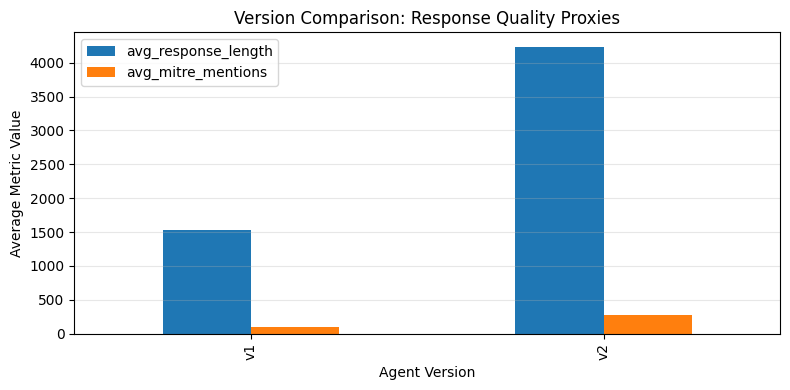

In [13]:
if not regression_df.empty:
    metric_df = (
        regression_df.groupby("version", as_index=False)[["response_length", "mitre_mentions"]]
        .mean()
        .rename(columns={"response_length": "avg_response_length", "mitre_mentions": "avg_mitre_mentions"})
    )

    fig, ax = plt.subplots(figsize=(8, 4))
    metric_df.set_index("version")[["avg_response_length", "avg_mitre_mentions"]].plot(kind="bar", ax=ax)
    ax.set_title("Version Comparison: Response Quality Proxies")
    ax.set_xlabel("Agent Version")
    ax.set_ylabel("Average Metric Value")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    metric_df
else:
    pd.DataFrame([{"status": "No regression data available"}])

## Workshop Wrap-Up

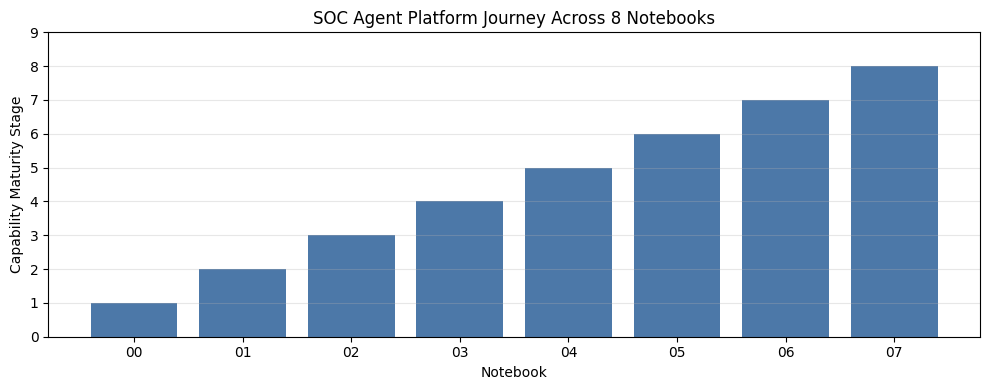

,notebook,theme,maturity_stage
0,00,Environment & Setup,1
1,01,Single-Agent Triage,2
2,02,Tool-Using Agents,3
3,03,Memory & Context,4
4,04,Multi-Agent Collaboration,5
5,05,Evaluation & Guardrails,6
6,06,Operational Monitoring,7
7,07,Versioned Production Agents,8


In [14]:
workshop_df = pd.DataFrame([
    {"notebook": "00", "theme": "Environment & Setup", "maturity_stage": 1},
    {"notebook": "01", "theme": "Single-Agent Triage", "maturity_stage": 2},
    {"notebook": "02", "theme": "Tool-Using Agents", "maturity_stage": 3},
    {"notebook": "03", "theme": "Memory & Context", "maturity_stage": 4},
    {"notebook": "04", "theme": "Multi-Agent Collaboration", "maturity_stage": 5},
    {"notebook": "05", "theme": "Evaluation & Guardrails", "maturity_stage": 6},
    {"notebook": "06", "theme": "Operational Monitoring", "maturity_stage": 7},
    {"notebook": "07", "theme": "Versioned Production Agents", "maturity_stage": 8},
])

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(workshop_df["notebook"], workshop_df["maturity_stage"], color="#4C78A8")
ax.set_title("SOC Agent Platform Journey Across 8 Notebooks")
ax.set_xlabel("Notebook")
ax.set_ylabel("Capability Maturity Stage")
ax.set_ylim(0, 9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

workshop_df

### (Optional) clean up agents

In [ ]:
# (optional) uncomment to cleanup created agents
# try:
#     if agent_v1 is not None:
#         project_client.agents.delete_version(agent_name="soc-triage-agent", agent_version=agent_v1.version)
#     if agent_v2 is not None:
#         project_client.agents.delete_version(agent_name="soc-triage-agent", agent_version=agent_v2.version)
#     if dev_agent is not None:
#         project_client.agents.delete_version(agent_name="soc-triage-agent-dev", agent_version=dev_agent.version)
#     if prod_agent is not None:
#         project_client.agents.delete_version(agent_name="soc-triage-agent-prod", agent_version=prod_agent.version)
#     print("Cleanup complete: deleted created agent versions.")
# except AttributeError:
#     print("Versioned agents require azure-ai-projects>=2.0.0b4")

Cleanup complete: deleted created agent versions.


You've now built a complete SOC agent platform: from single agents â†’ multi-agent teams â†’ evaluation â†’ production. Time to investigate some real incidents!

## Summary of this notebook
- Create and compare versioned agents, then continue a conversation with the Responses API.
- List versions, model dev vs prod separation, and run regression checks.
- Wrap up with a maturity overview and clean up created agents.